In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
# create a convolution instance

# create a conv2d class instance wth parameters
in_channels = 3 # RGB images have 3 channels --> it is not the size of the image but the number of channels (depth)
out_channels = 15 # the output will have 15 channels, which means that the conv layer will learn 15 filters (kernels) to apply to the input image
kernel_size = 5
stride = 1
padding = 0

# create the instance of the conv2d class
conv_layer = nn.Conv2d(in_channels=in_channels,
                       out_channels=out_channels,
                       kernel_size=kernel_size,
                       stride=stride, # it assumes same value for both dimensions (height and width)
                       padding=padding)

print(conv_layer)
print("Size of the weight matrix (filters): ", conv_layer.weight.shape) # (out_channels, in_channels, kernel_size, kernel_size)
print("Size of the bias vector: ", conv_layer.bias.shape) # (out_channels)

Conv2d(3, 15, kernel_size=(5, 5), stride=(1, 1))
Size of the weight matrix (filters):  torch.Size([15, 3, 5, 5])
Size of the bias vector:  torch.Size([15])


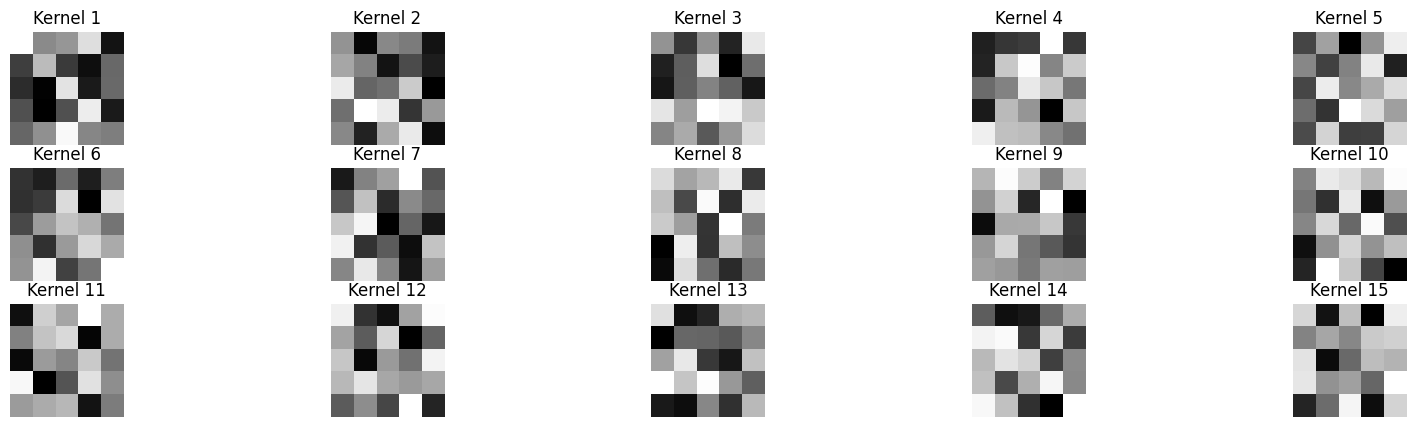

In [4]:
# what do these kernels look like?
# we can visualize the kernels by plotting them as images

fig, ax = plt.subplots(3, out_channels // 3, figsize=(20, 5))

for i, ax in enumerate(ax.flatten()):
    ax.imshow(torch.squeeze(conv_layer.weight[i, 0, :, :]).detach().numpy(), cmap="gray") # we take the first channel of the kernel (since we have 3 channels, we can visualize each one separately)
    ax.set_title(f"Kernel {i+1}")
    ax.axis("off")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.5104709..3.9147646].


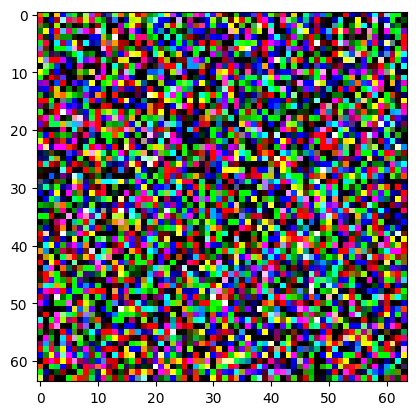

In [5]:
# convolve with an image

imsize = (1, 3, 64, 64) # (num_images, in_channels, height, width)
img = torch.randn(imsize) # create a random image with the specified size

# pytorch wants channels first, but matplotlib wants channels last, so we need to permute the dimensions of the image before plotting it
img2view = img.permute(2, 3, 1, 0).numpy() # (height, width, in_channels, num_images)

plt.imshow(np.squeeze(img2view)) # we take the first image (since we have only one) and we squeeze the dimensions to get rid of the num_images dimension

In [6]:
# convolve the image with the filter bank

conv_result = conv_layer(img) # (num_images, out_channels, height_out, width_out)

print("Size of the input image: ", img.shape) # (num_images, in_channels, height, width)
print("Size of the convolution result: ", conv_result.shape) # (num_images, out_channels, height_out, width_out)

# the output size is 64, following the equation output_size = (input_size - kernel_size + 2*padding) / stride + 1
# in our case, output_size = (64 - 5 + 2*0) / 1 + 1 = 60, so the output size is (num_images, out_channels, 60, 60)

Size of the input image:  torch.Size([1, 3, 64, 64])
Size of the convolution result:  torch.Size([1, 15, 60, 60])


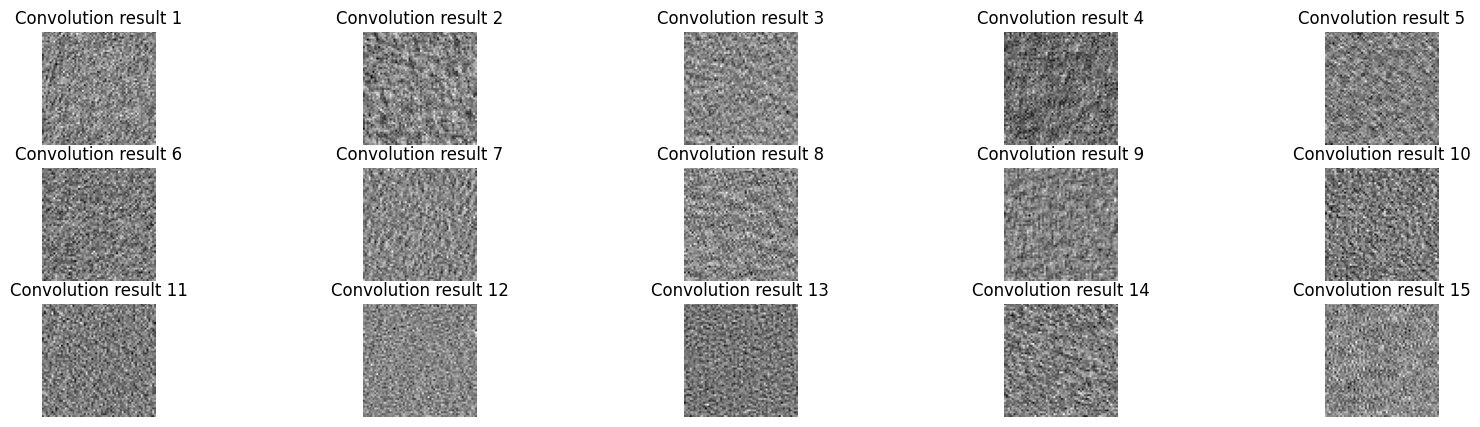

In [7]:
# what do the convolution results look like?

fig, ax = plt.subplots(3, out_channels // 3, figsize=(20, 5))

for i, ax in enumerate(ax.flatten()):
    ax.imshow(torch.squeeze(conv_result[0, i, :, :]).detach().numpy(), cmap="gray") # we take the first image (since we have only one) and we take the i-th channel of the convolution result
    ax.set_title(f"Convolution result {i+1}")
    ax.axis("off")

In [8]:
# another example: if we have an image of size 1x256x256 and we want a result of 1x252x84

in_channels = 1 # the input image has 1 channel (grayscale)
img_size = [256, 256] # the input image has a size of 256x256
out_channels = 1 # we want the output to have 1 channel (grayscale)
kernel_size = 7
stride = (1, 3)
padding = 1

conv_layer2 = nn.Conv2d(in_channels=in_channels,
                        out_channels=out_channels,
                        kernel_size=kernel_size,
                        stride=stride,
                        padding=padding)

img = torch.randn(1, in_channels, img_size[0], img_size[1]) # create a random image with the specified size
conv_result2 = conv_layer2(img)

print("Size of the input image: ", img.shape) # (num_images, in_channels, height, width)
print("Size of the convolution result: ", conv_result2.shape) # (num_images, out_channels, height_out, width_out)

Size of the input image:  torch.Size([1, 1, 256, 256])
Size of the convolution result:  torch.Size([1, 1, 252, 84])


In [9]:
# exercise: convolve an image of size 3x64x64 to produce a 10x28x28 output and figure 
# out what the parameters of the conv layer should be (kernel size, stride, padding)
# if it is decimal normally it is rounded down using floor.

in_channels = 3
img_size = [64, 64]
out_channels = 10

# we can use the equation output_size = (input_size - kernel_size + 2*padding) / stride + 1 to figure out the parameters of the conv layer
# (64 - kernel_size + 2*padding) / stride + 1

kernel_size = 9
stride = 2
padding = 0

print((64 - kernel_size + 2*padding) / stride + 1) # size out

conv_layer3 = nn.Conv2d(in_channels=in_channels,
                        out_channels=out_channels,
                        kernel_size=kernel_size,
                        stride=stride,
                        padding=padding)
img = torch.randn(1, in_channels, img_size[0], img_size[1]) # create a random image with the specified size
conv_result3 = conv_layer3(img)

print("Size of the input image: ", img.shape) # (num_images, in_channels, height, width)
print("Size of the convolution result: ", conv_result3.shape) # (num_images,

28.5
Size of the input image:  torch.Size([1, 3, 64, 64])
Size of the convolution result:  torch.Size([1, 10, 28, 28])


In [10]:
# tranposed convolution or also called deconvolution
# it is used to upsample an image, it is the opposite of convolution

# example
in_channels = 3 # RGB
out_channels = 15
kernel_size = 5
stride = 1
padding = 0

deconv_layer = nn.ConvTranspose2d(in_channels=in_channels,
                                out_channels=out_channels,
                                kernel_size=kernel_size,
                                stride=stride,
                                padding=padding)

print(deconv_layer)
print("Size of the weight matrix (filters): ", deconv_layer.weight.shape) # (in_channels, out_channels, kernel_size, kernel_size)
print("Size of the bias vector: ", deconv_layer.bias.shape) # (in_channels)

ConvTranspose2d(3, 15, kernel_size=(5, 5), stride=(1, 1))
Size of the weight matrix (filters):  torch.Size([3, 15, 5, 5])
Size of the bias vector:  torch.Size([15])


In [11]:
image = torch.randn(1, in_channels, 64, 64) # create a random image with the specified size
deconv_result = deconv_layer(image)
print("Size of the input image: ", image.shape) # (num_images, in_channels, height, width)
print("Size of the deconvolution result: ", deconv_result.shape) # (num_images, out_channels, height_out, width_out)

Size of the input image:  torch.Size([1, 3, 64, 64])
Size of the deconvolution result:  torch.Size([1, 15, 68, 68])


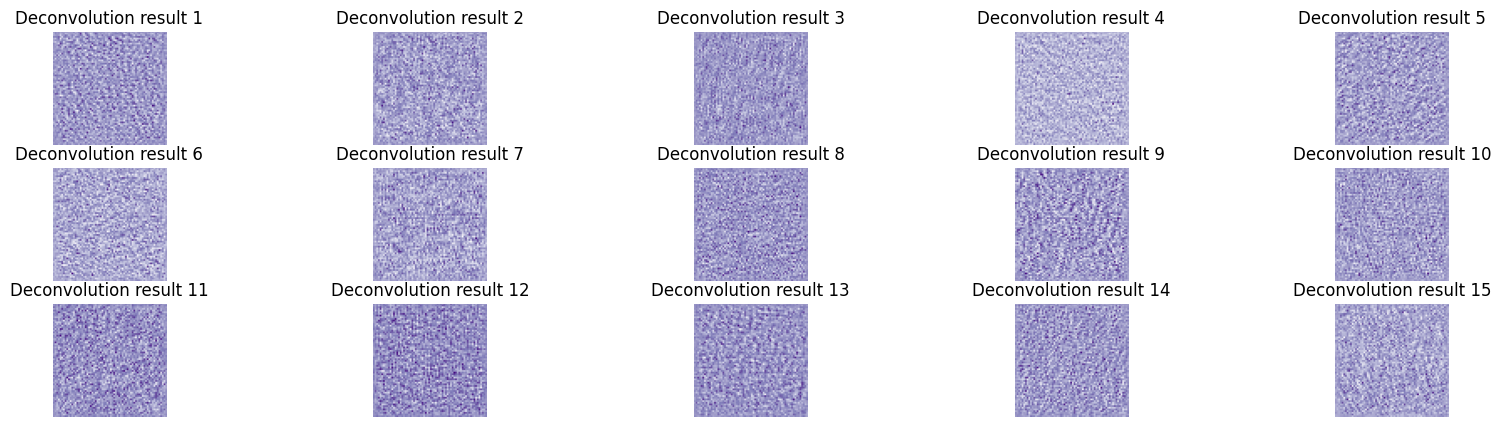

In [12]:
# plot the deconvolution result
fig, ax = plt.subplots(3, out_channels // 3, figsize=(20, 5))
for i, ax in enumerate(ax.flatten()):
    ax.imshow(torch.squeeze(deconv_result[0, i, :, :]).detach().numpy(), cmap="Purples") # we take the first image (since we have only one) and we take the i-th channel of the deconvolution result
    ax.set_title(f"Deconvolution result {i+1}")
    ax.axis("off")

In [15]:
# create a pool class instance with parameters

pool_kernel_size = 3
pool_stride = 3

# create the instance of the max pool class
pool_layer_2d = nn.MaxPool2d(kernel_size=pool_kernel_size, stride=pool_stride)
pool_layer_3d = nn.MaxPool3d(kernel_size=pool_kernel_size, stride=pool_stride)

print(pool_layer_2d)
print(pool_layer_3d)

MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
MaxPool3d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)


In [18]:
img2d = torch.randn(1, 1, 30, 30) # create a random image with the specified size
img3d = torch.randn(1, 3, 30, 30) # create a random image with the specified size

pool_result_2d_pool2d = pool_layer_2d(img2d)
pool_result_3d_pool2d = pool_layer_2d(img3d)
pool_result_3d_pool3d = pool_layer_3d(img3d)

print("Size of the input image (2D): ", img2d.shape) # (num_images, in_channels, height, width)
print("Size of the input image (3D): ", img3d.shape) # (num_images, in_channels, height, width)

print("Size of the pooled image (2D): ", pool_result_2d_pool2d.shape) # (num_images, in_channels, height, width)
print("Size of the pooled image (3D) with 2D pooling: ", pool_result_3d_pool2d.shape) # (num_images, in_channels, height, width)
print("Size of the pooled image (3D) with 3D pooling: ", pool_result_3d_pool3d.shape) # (num_images, in_channels, height, width)

Size of the input image (2D):  torch.Size([1, 1, 30, 30])
Size of the input image (3D):  torch.Size([1, 3, 30, 30])
Size of the pooled image (2D):  torch.Size([1, 1, 10, 10])
Size of the pooled image (3D) with 2D pooling:  torch.Size([1, 3, 10, 10])
Size of the pooled image (3D) with 3D pooling:  torch.Size([1, 1, 10, 10])


In [23]:
# create a simple cnn as an example of how to use the conv and pool layers together

little_net = nn.Sequential(
    # the conv-pool blocks are the building blocks of a cnn, we can stack them to create a deeper network
    nn.Conv2d(in_channels=3, out_channels=10, kernel_size=5, stride=3, padding=2), 
    nn.ReLU(),
    nn.AvgPool3d(kernel_size=3, stride=3),

    # the FNN blocks are the fully connected layers, they are used to classify the features extracted by the conv-pool blocks
    nn.Flatten(), # flatten the output of the conv-pool blocks to feed it to the fully connected layers
    nn.Linear(in_features=588, out_features=1), # the input features are the number of channels multiplied by the height and width of the output of the conv-pool blocks
    nn.Sigmoid()
)

img = torch.rand(1, 3, 128, 128) # create a random image with the specified size
output = little_net(img)
print("Size of the output: ", output.shape) # (num_images, out_features)
print("Output: ", output)

Size of the output:  torch.Size([1, 1])
Output:  tensor([[0.5117]], grad_fn=<SigmoidBackward0>)
